In [1]:
from os.path import join
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from metrics import SERIES_ANALYSIS_LABELS, Compare, Mask, Region, prettyPrintTable
from scipy.stats import cumfreq
from skimage import measure

Metric functions using: cuda


In [2]:
DO_VOL = True
DO_SA = True
DO_DISPLACEMENT = True
DO_BSD = True
DO_SEP_F = True
DO_SEP_S = True
DO_SEP_RCVS = True
DO_PERC_F = True

In [ ]:
t = perf_counter()
OBJ = ["bladder", "prostate", "rectum", "femoral_head_l", "femoral_head_r"]

load = lambda x: [
    Mask(np.load(join("..", "data", f"{x}_{obj}.npy")).transpose(2, 1, 0)) for obj in OBJ
]

masksU = load("prostate_upright")
masksS = load("prostate_supine")

anchorU = Mask(masksU[3].mask | masksU[4].mask).center_of_mass
anchorS = Mask(masksS[3].mask | masksS[4].mask).center_of_mass

regionU = Region(*masksU[0:3], target="prostate", anchor=anchorU, labels=OBJ[:3])
regionS = Region(*masksS[0:3], target="prostate", anchor=anchorS, labels=OBJ[:3])

comp = Compare(regionU, regionS)
print(f"\n0. loading ============================> (t = {perf_counter() - t:.3f}s)")

SHAPE = masksU[0].mask.shape


0. loading ============================> (t = 2.533s)


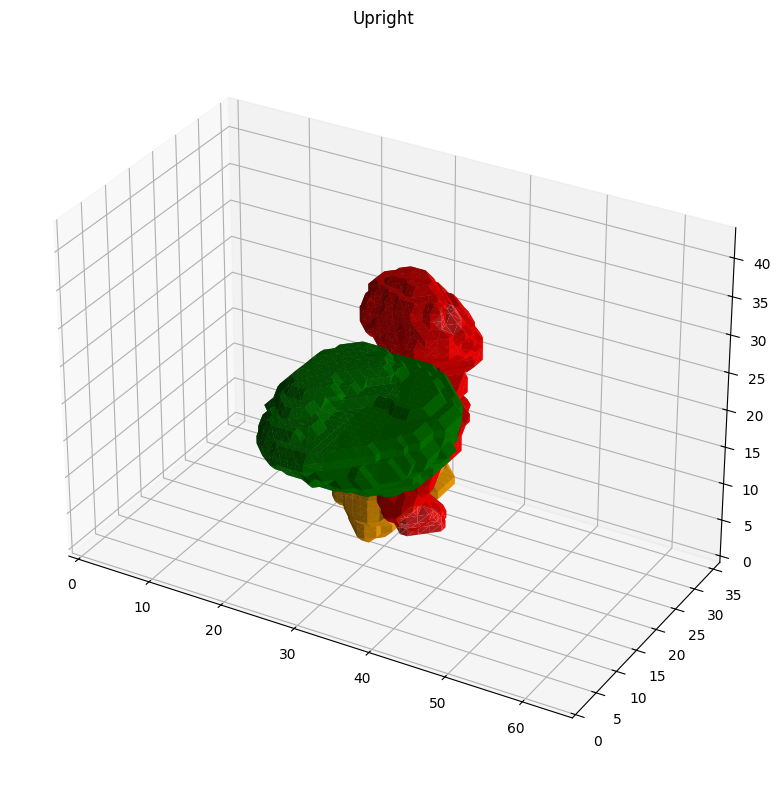

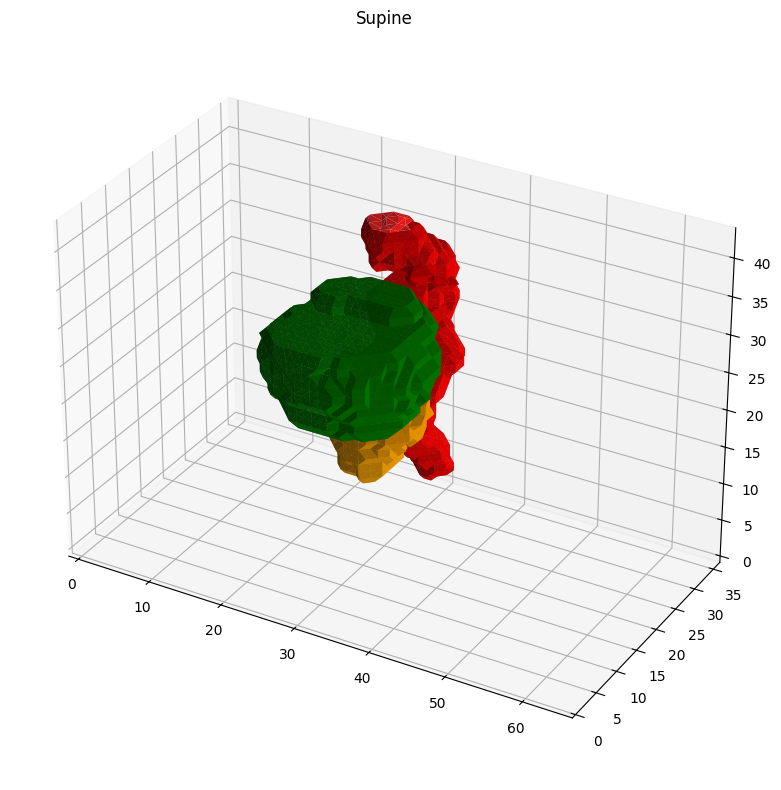

In [4]:
CLR = ["green", "orange", "red", "blue", "purple"]

def show3D(matrix, title="", size=(8, 8), downsample=1):
    matrix = matrix[::downsample, ::downsample, ::downsample]

    labels = np.unique(matrix)
    labels = labels[labels != 0]

    fig = plt.figure(figsize=size)
    ax = fig.add_subplot(projection="3d")

    for i, label in enumerate(labels):
        mask = (matrix == label).astype(np.uint8)

        if np.sum(mask) == 0:
            continue

        verts, faces, _, _ = measure.marching_cubes(mask, level=0)

        ax.plot_trisurf(
            verts[:, 0],
            verts[:, 1],
            faces,
            verts[:, 2],
            color=CLR[i],
            linewidth=0,
            antialiased=True,
            alpha=0.9,
        )

    zdim, ydim, xdim = matrix.shape
    ax.set_xlim(0, zdim)
    ax.set_ylim(0, ydim)
    ax.set_zlim(0, xdim)
    ax.set_box_aspect(matrix.shape)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

combU = np.zeros(SHAPE, dtype=int)
combS = np.zeros(SHAPE, dtype=int)

for i, m in enumerate(regionU.masks):
    combU[m.getMaskCoordinates()] = i + 1

for i, m in enumerate(regionS.masks):
    combS[m.getMaskCoordinates()] = i + 1

show3D(combU, "Upright", downsample=4)
show3D(combS, "Supine", downsample=4)

# Volumetric / Surface Area Analysis

In [5]:
if DO_VOL:
    t = perf_counter()
    V = list(comp.getVolDiff(diff_only=False).values())
    labels = ["vol diff", "upright Vol", "supine Vol"]
    print(f"\n1. volume diff ========================> (t = {perf_counter() - t:.3f}s)")
    prettyPrintTable(OBJ[:3], V, labels)


1. volume diff ========================> (t = 0.000s)
+----------+----------+-------------+------------+
|          | vol diff | upright Vol | supine Vol |
+----------+----------+-------------+------------+
| bladder  | -11395   | 166215      | 154820     |
+----------+----------+-------------+------------+
| prostate | -7975    | 50735       | 42760      |
+----------+----------+-------------+------------+
| rectum   | -5695    | 101140      | 95445      |
+----------+----------+-------------+------------+


In [6]:
if DO_SA:
    t = perf_counter()
    SA = list(comp.getSADiff(diff_only=False).values())
    labels = ["sa diff", "upright sa", "supine sa"]
    print(f"\n2. surface area diff ==================> (t = {perf_counter() - t:.3f}s)")
    prettyPrintTable(OBJ[:3], SA, labels)


2. surface area diff ==================> (t = 0.000s)
+----------+---------+------------+-----------+
|          | sa diff | upright sa | supine sa |
+----------+---------+------------+-----------+
| bladder  | -4438   | 24949      | 20511     |
+----------+---------+------------+-----------+
| prostate | -1989   | 10484      | 8495      |
+----------+---------+------------+-----------+
| rectum   | -226    | 22102      | 21876     |
+----------+---------+------------+-----------+


# ROI Displacement / Alignment Analysis

In [7]:
if DO_DISPLACEMENT:
    t = perf_counter()
    DISP = list(comp.getROIDisplacementDiff().values())
    labels = ["L(-ve)/R(+ve)", "A(-ve)/P(+ve)", "I(-ve)/S(+ve)", "Magnitude"]
    print(f"\n3. roi displacement ===================> (t = {perf_counter() - t:.3f}s)")
    prettyPrintTable(OBJ[:3], DISP, labels)


3. roi displacement ===================> (t = 0.000s)
+----------+---------------+---------------+---------------+-----------+
|          | L(-ve)/R(+ve) | A(-ve)/P(+ve) | I(-ve)/S(+ve) | Magnitude |
+----------+---------------+---------------+---------------+-----------+
| bladder  | -15.039       | 12.635        | -14.203       | 24.239    |
+----------+---------------+---------------+---------------+-----------+
| prostate | -13.116       | 11.174        | -9.491        | 19.671    |
+----------+---------------+---------------+---------------+-----------+
| rectum   | -12.356       | 11.76         | 7.628         | 18.686    |
+----------+---------------+---------------+---------------+-----------+


# Bidirectional Surface Discrepancy

In [8]:
if DO_BSD:
    t = perf_counter()
    ASD = list(comp.getBSDDiff("asd").values())
    HD95 = list(comp.getBSDDiff("hd95").values())
    HD = list(comp.getBSDDiff("hd").values())
    print(f"\n4. bidirectional surface discrepancy ==> (t = {perf_counter() - t:.3f}s)")
    prettyPrintTable(OBJ[:3], [ASD, HD95, HD], ["ASD", "HD95", "HD"])


4. bidirectional surface discrepancy ==> (t = 8.041s)
+----------+--------+-------+--------+
|          | ASD    | HD95  | HD     |
+----------+--------+-------+--------+
| bladder  | 2.23   | 1.794 | 6.344  |
+----------+--------+-------+--------+
| prostate | 9.0    | 7.141 | 20.248 |
+----------+--------+-------+--------+
| rectum   | 14.866 | 13.0  | 26.796 |
+----------+--------+-------+--------+


# Masked Distance Map

## Separation Distance

In [9]:
if DO_SEP_F:
    t = perf_counter()
    data = comp.getSeparationDistanceDiff("volume")
    print(f"\n5. separation distance (vol) ===========> (t = {perf_counter() - t:.3f}s)")
    for loc, dat in data.items():
        print(f"\n\t[{loc}]")
        prettyPrintTable(["diff", "upright", "supine"], dat, SERIES_ANALYSIS_LABELS)


5. separation distance (vol) ===========> (t = 0.250s)

	[bladder]
+---------+-----+--------+--------+--------+--------+--------+--------+--------+
|         | MIN | P05    | P10    | AVG    | MDN    | P90    | P95    | MAX    |
+---------+-----+--------+--------+--------+--------+--------+--------+--------+
| diff    | 0.0 | -1.101 | -1.652 | -1.356 | -2.556 | 1.281  | 3.187  | 4.151  |
+---------+-----+--------+--------+--------+--------+--------+--------+--------+
| upright | 0.0 | 4.899  | 7.348  | 22.813 | 22.0   | 39.294 | 43.795 | 56.763 |
+---------+-----+--------+--------+--------+--------+--------+--------+--------+
| supine  | 0.0 | 6.0    | 9.0    | 24.168 | 24.556 | 38.013 | 40.608 | 52.612 |
+---------+-----+--------+--------+--------+--------+--------+--------+--------+

	[rectum]
+---------+-----+-------+--------+--------+-------+--------+--------+--------+
|         | MIN | P05   | P10    | AVG    | MDN   | P90    | P95    | MAX    |
+---------+-----+-------+--------+

In [10]:
if DO_SEP_S:
    t = perf_counter()
    data = comp.getSeparationDistanceDiff("surface")
    print(f"\n6. separation distance (surface) =======> (t = {perf_counter() - t:.3f}s)")
    for loc, dat in data.items():
        print(f"\n\t[{loc}]")
        prettyPrintTable(["diff", "upright", "supine"], dat, SERIES_ANALYSIS_LABELS)


6. separation distance (surface) =======> (t = 0.160s)

	[bladder]
+---------+-----+-----+--------+--------+--------+--------+--------+--------+
|         | MIN | P05 | P10    | AVG    | MDN    | P90    | P95    | MAX    |
+---------+-----+-----+--------+--------+--------+--------+--------+--------+
| diff    | 0.0 | 0.0 | -1.641 | -0.411 | -2.002 | 3.008  | 3.421  | 4.151  |
+---------+-----+-----+--------+--------+--------+--------+--------+--------+
| upright | 0.0 | 1.0 | 4.359  | 26.26  | 26.721 | 45.222 | 48.703 | 56.763 |
+---------+-----+-----+--------+--------+--------+--------+--------+--------+
| supine  | 0.0 | 1.0 | 6.0    | 26.671 | 28.723 | 42.214 | 45.282 | 52.612 |
+---------+-----+-----+--------+--------+--------+--------+--------+--------+

	[rectum]
+---------+-----+-------+--------+--------+--------+--------+--------+--------+
|         | MIN | P05   | P10    | AVG    | MDN    | P90    | P95    | MAX    |
+---------+-----+-------+--------+--------+--------+-------

In [11]:
if DO_SEP_RCVS:
    t = perf_counter()
    data = comp.getSeparationDistanceDiff("rcvs")
    print(f"\n7. separation distance (rcvs) ==========> (t = {perf_counter() - t:.3f}s)")
    for loc, dat in data.items():
        print(f"\n\t[{loc}]")
        prettyPrintTable(["diff", "upright", "supine"], dat, SERIES_ANALYSIS_LABELS)


7. separation distance (rcvs) ==========> (t = 54.229s)

	[bladder]
+---------+-----+-----+-----+--------+-------+--------+--------+--------+
|         | MIN | P05 | P10 | AVG    | MDN   | P90    | P95    | MAX    |
+---------+-----+-----+-----+--------+-------+--------+--------+--------+
| diff    | 0.0 | 0.0 | 0.0 | 4.256  | 0.55  | 15.901 | 20.01  | 21.714 |
+---------+-----+-----+-----+--------+-------+--------+--------+--------+
| upright | 0.0 | 1.0 | 1.0 | 14.795 | 11.18 | 36.248 | 42.682 | 52.65  |
+---------+-----+-----+-----+--------+-------+--------+--------+--------+
| supine  | 0.0 | 1.0 | 1.0 | 10.54  | 10.63 | 20.347 | 22.672 | 30.935 |
+---------+-----+-----+-----+--------+-------+--------+--------+--------+

	[rectum]
+---------+-----+-------+-------+--------+--------+---------+---------+--------+
|         | MIN | P05   | P10   | AVG    | MDN    | P90     | P95     | MAX    |
+---------+-----+-------+-------+--------+--------+---------+---------+--------+
| diff    |

## Discretised Distance Thresholding / Distance-Volume Histogram


8. percentage overlap (volume) =========> (t = 1.670s)

	[bladder]
+---------+-------+-------+-------+-------+-------+--------+--------+------+
|         | MIN   | P05   | P10   | AVG   | MDN   | P90    | P95    | MAX  |
+---------+-------+-------+-------+-------+-------+--------+--------+------+
| diff    | -0.0  | 0.008 | 0.024 | 0.056 | 0.131 | -0.002 | -0.001 | -0.0 |
+---------+-------+-------+-------+-------+-------+--------+--------+------+
| upright | 0.001 | 0.028 | 0.069 | 0.592 | 0.677 | 0.99   | 0.997  | 1.0  |
+---------+-------+-------+-------+-------+-------+--------+--------+------+
| supine  | 0.001 | 0.02  | 0.045 | 0.536 | 0.547 | 0.992  | 0.998  | 1.0  |
+---------+-------+-------+-------+-------+-------+--------+--------+------+

	[rectum]
+---------+--------+--------+--------+--------+--------+--------+--------+-----+
|         | MIN    | P05    | P10    | AVG    | MDN    | P90    | P95    | MAX |
+---------+--------+--------+--------+--------+--------+--------+-

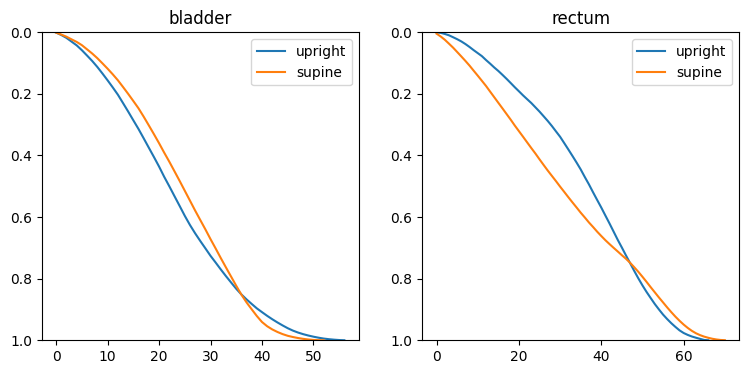

In [12]:
if DO_PERC_F:
    t = perf_counter()
    data = comp.getPercentageOverlapDiff("volume", percentages_only=False)
    print(f"\n8. percentage overlap (volume) =========> (t = {perf_counter() - t:.3f}s)")

    fig, axs = plt.subplots(1, 2, figsize=(9, 4))

    for ax, (loc, dat) in zip(axs, data.items()):
        print(f"\n\t[{loc}]")
        prettyPrintTable(["diff", "upright", "supine"], dat[0:3], SERIES_ANALYSIS_LABELS)

        ax.set_title(loc)
        ax.set_ylim(1.0, 0.0)
        ax.plot(dat[3], label="upright")
        ax.plot(dat[7], label="supine")
        ax.legend()
